In [8]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean as cmo

In [9]:
path_raw = '/data/globus/jbassham/thesis-rough/raw/south/04082026_0901'
path_regrid = '/data/globus/jbassham/thesis-rough/regrid/south/04142026_1912'

In [10]:
raw_data = np.load(Path(path_raw) / 'wind_raw_era5_v1_reg.npz')
regrid_data = np.load(Path(path_regrid) / 'wind_regrid_era5_v1.npz')

In [11]:
def plot_original_and_regrid(
        data_raw, data_regrid,
        time_index,
        var_name: str,
        raw_bounds: None | dict = None,
        regrid_bounds: None | dict = None,
        ) -> None:
    """
    
    """
    fig, axs = plt.subplots(
        nrows = 2, ncols = 1, figsize = (6, 6), constrained_layout = True,
    )

    if raw_bounds is not None:     
        pcm0 = axs[0].pcolormesh(
            data_raw[var_name][
                time_index, 
                raw_bounds['y'][0]:raw_bounds['y'][1], 
                raw_bounds['x'][0]:raw_bounds['x'][1]
                ]
        )

    else:
        pcm0 = axs[0].pcolormesh(
            data_raw[var_name][time_index]
        )
           
    axs[0].set_title('Raw')
    plt.colorbar(pcm0, ax = axs[0], orientation = 'vertical')

            
    if regrid_bounds is not None:  
        pcm1 = axs[1].pcolormesh(
            data_regrid[var_name][
                time_index, 
                regrid_bounds['y'][0]:regrid_bounds['y'][1], 
                regrid_bounds['x'][0]:regrid_bounds['x'][1]
                ]
            )
        
    else:
        pcm1 = axs[1].pcolormesh(
            data_regrid[var_name][time_index]
            )

    axs[1].set_title('Regrid')
    plt.colorbar(pcm1, ax = axs[1], orientation = 'vertical')


    fig.suptitle(var_name, fontweight = 'bold')

    plt.show

In [12]:
time_index = 100

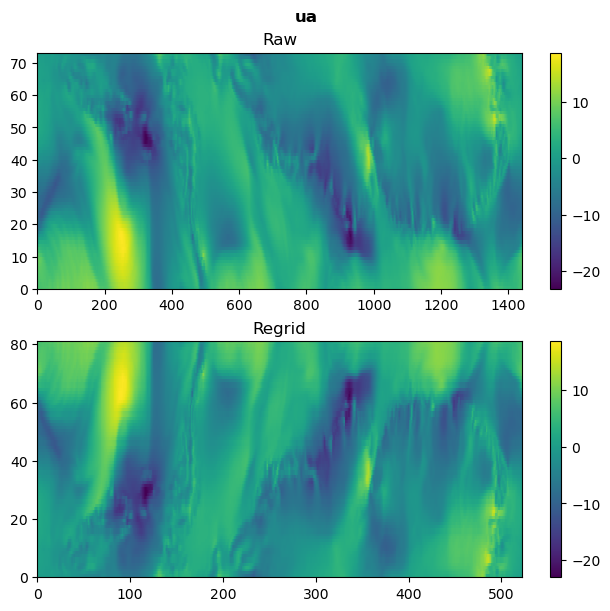

In [13]:
plot_original_and_regrid(raw_data, regrid_data, time_index, 'ua')